# Etapa 2 CRISP-DM — Comprensión de los datos
## Proyecto 09: reingreso hospitalario en pacientes con diabetes

**UTEC · Proyecto Integrador I · Grupo 2**

Este notebook cubre las tareas 2.1 a 2.4: recopilar, describir, explorar y
verificar la calidad. Es un análisis descriptivo y exploratorio. `df_parquet` conserva todos
los episodios originales y `df_cohort` es solamente la vista exploratoria que
separa los destinos de alta que indican fallecimiento.

## Etapas

| Tarea | Salida en este notebook |
|---|---|
| 2.1 Recopilar | fuentes, acceso y problemas observados |
| 2.2 Describir | unidad de análisis, volumen, variables y resultado |
| 2.3 Explorar | distribuciones, relaciones, siete tipos de gráficos y tres hallazgos |
| 2.4 Verificar | faltantes, códigos, duplicados, cardinalidad, atípicos y representatividad |

El material de referencia es `Clases/crispdm_e1_e2.md`. La procedencia de los
datos es Diabetes 130-US Hospitals for years 1999–2008, UCI, dataset 296.

# Configuración inicial

In [1]:
import io
import re
from pathlib import Path

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 100)

SEED = 42
np.random.seed(SEED)

# Rutas relativas a la raíz del repositorio (el notebook vive en notebooks/).
REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = REPO / "data"
FIG_DIR = REPO / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

def guardar(fig, nombre):
    """Guarda la figura en reports/figures/ para poder citarla en el informe."""
    ruta = FIG_DIR / f"{nombre}.png"
    fig.savefig(ruta, dpi=150, bbox_inches="tight")
    return ruta

print(f"Repositorio: {REPO}")
print(f"Datos:       {DATA_DIR}")
print(f"Figuras:     {FIG_DIR}")


Repositorio: /home/claude/capstone-p09-reingreso
Datos:       /home/claude/capstone-p09-reingreso/data
Figuras:     /home/claude/capstone-p09-reingreso/reports/figures


# 2.1 · Recopilar los datos iniciales

Las fuentes de trabajo son los dos archivos compartidos en Google Drive. Se
mantienen aquí las URL entregadas por el equipo y los nombres `df_parquet` y
`df_mapping`. El CSV de códigos es concatenado: contiene tres bloques con
cabeceras distintas, por lo que primero se lee como dos columnas y después se
separa por cabecera. No se debe tratar todo el CSV como un único diccionario.

In [2]:
# Rutas del repositorio. Los datos viven en data/ para que el análisis sea
# reproducible con `git clone` + un solo comando, sin depender de servicios externos.
RUTA_PARQUET = DATA_DIR / "diabetes_readmission.parquet"
RUTA_IDS = DATA_DIR / "ids_mapping.csv"

# Respaldo: copia compartida por el equipo en Drive, sólo si el archivo local no está.
DRIVE_PARQUET = "https://drive.google.com/uc?export=download&id=122SIHS0YFXUi6K1x2D2cVP_iOLtk9oZT"
DRIVE_IDS = "https://drive.google.com/uc?export=download&id=136U7krs2lICcTFURWN2bxHJSwJ8NP771"

origen_parquet = RUTA_PARQUET if RUTA_PARQUET.exists() else DRIVE_PARQUET
origen_ids = RUTA_IDS if RUTA_IDS.exists() else DRIVE_IDS

df_parquet = pd.read_parquet(origen_parquet)
df_mapping = pd.read_csv(
    origen_ids,
    header=None,
    names=["codigo", "description"],
    dtype="string",
    keep_default_na=False,
)

print(f"Origen de los datos: {'repositorio (data/)' if RUTA_PARQUET.exists() else 'Drive (respaldo)'}")
print(f"Parquet: {df_parquet.shape[0]:,} filas y {df_parquet.shape[1]} columnas")
print(f"CSV de códigos: {len(df_mapping):,} líneas, incluidos separadores")
display(df_parquet.head(3))


Origen de los datos: repositorio (data/)
Parquet: 101,766 filas y 50 columnas
CSV de códigos: 68 líneas, incluidos separadores


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO


In [3]:
# El CSV de Drive trae tres bloques: una cabecera identifica cada variable.
variables_codificadas = {
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id",
}

def separar_mapping(tabla):
    bloques = []
    variable_actual = None
    for _, fila in tabla.iterrows():
        codigo = str(fila["codigo"]).strip()
        descripcion = str(fila["description"]).strip()
        if codigo in variables_codificadas and descripcion == "description":
            variable_actual = codigo
        elif variable_actual and codigo:
            bloques.append(
                {
                    "variable": variable_actual,
                    "codigo": int(codigo),
                    "description": descripcion,
                }
            )
    return pd.DataFrame(bloques)

mapping_table = separar_mapping(df_mapping)
assert set(mapping_table["variable"]) == variables_codificadas
print("Bloques interpretados:", mapping_table.groupby("variable").size().to_dict())
display(mapping_table.head(10))

Bloques interpretados: {'admission_source_id': 25, 'admission_type_id': 8, 'discharge_disposition_id': 30}


,variable,codigo,description
0,admission_type_id,1,Emergency
1,admission_type_id,2,Urgent
2,admission_type_id,3,Elective
3,admission_type_id,4,Newborn
4,admission_type_id,5,Not Available
5,admission_type_id,6,NULL
6,admission_type_id,7,Trauma Center
7,admission_type_id,8,Not Mapped
8,discharge_disposition_id,1,Discharged to home
9,discharge_disposition_id,2,Discharged/transferred to another short term h...


### Acceso y problemas observados

- El Parquet conserva la tabla de episodios y el CSV conserva los significados
de los códigos administrativos. Ambos se leen directamente desde Drive; si el
acceso no está disponible, la ejecución debe detenerse y reportarse, no
presentar datos locales como si fueran de Drive.
- Una lectura única del CSV desplaza los bloques bajo la primera cabecera. El
parseo anterior conserva los tres nombres (`admission_type_id`,
`discharge_disposition_id` y `admission_source_id`) y convierte sus códigos a
enteros.
- Los archivos no incluyen fecha por episodio ni hospital. Por ello no se
pueden analizar tendencias temporales, tasas diarias o diferencias entre
centros.

# 2.2 · Describir los datos

Una fila representa un episodio de hospitalización (`encounter_id`) de un
paciente identificado por `patient_nbr`; un paciente puede aparecer en varios
episodios. El resultado observado es `readmitted`, con `NO`, `>30` y `<30`.
La documentación de la fuente cubre 1999–2008, pero el archivo no trae una
fecha por fila. El esquema siguiente describe las **50 columnas originales**;
no se agregan variables derivadas al conjunto completo.

In [4]:
identificador_cols = ["encounter_id", "patient_nbr"]
numericas_cols = [
    "time_in_hospital", "num_lab_procedures", "num_procedures",
    "num_medications", "number_outpatient", "number_emergency",
    "number_inpatient", "number_diagnoses",
]
target_col = "readmitted"
categoricas_cols = [
    c for c in df_parquet.columns
    if c not in identificador_cols + numericas_cols
]
assert len(df_parquet.columns) == 50
assert len(identificador_cols + numericas_cols + categoricas_cols) == 50

schema = pd.DataFrame({
    "variable": df_parquet.columns,
    "tipo pandas": [str(df_parquet[c].dtype) for c in df_parquet.columns],
    "tipo para E2": [
        "identificador técnico" if c in identificador_cols else
        "numérica discreta" if c in numericas_cols else
        "categórica / resultado" if c == target_col else
        "categórica"
        for c in df_parquet.columns
    ],
    "valores distintos": [df_parquet[c].nunique(dropna=True) for c in df_parquet.columns],
    "% faltantes (raw)": [df_parquet[c].isna().mean() * 100 for c in df_parquet.columns],
})
print(f"Unidad: episodio hospitalario | {len(df_parquet):,} filas | {len(schema)} variables")
display(schema.round({"% faltantes (raw)": 2}))

Unidad: episodio hospitalario | 101,766 filas | 50 variables


,variable,tipo pandas,tipo para E2,valores distintos,% faltantes (raw)
0,encounter_id,int64,identificador técnico,101766,0.00
1,patient_nbr,int64,identificador técnico,71518,0.00
2,race,str,categórica,5,2.23
3,gender,str,categórica,3,0.00
4,age,str,categórica,10,0.00
5,weight,str,categórica,9,96.86
6,admission_type_id,int64,categórica,8,0.00
7,discharge_disposition_id,int64,categórica,26,0.00
8,admission_source_id,int64,categórica,17,0.00
9,time_in_hospital,int64,numérica discreta,14,0.00


In [5]:
# Resúmenes compactos para magnitudes y resultado.

resumen_parquet = df_parquet[numericas_cols].describe().T[
    ["count", "mean", "50%", "std", "min", "max"]
].rename(columns={"50%": "median"})
print("Magnitudes numéricas del raw:")
display(resumen_parquet.round(2))

resumen_vategorico = pd.DataFrame({
    "variable": categoricas_cols,
    "moda": [df_parquet[c].mode(dropna=True).iloc[0] if df_parquet[c].notna().any() else pd.NA for c in categoricas_cols],
    "frecuencia moda": [df_parquet[c].value_counts(dropna=True).iloc[0] if df_parquet[c].notna().any() else 0 for c in categoricas_cols],
}).set_index("variable")
print("Primeras variables categóricas (el esquema anterior contiene las 50):")
display(resumen_vategorico.head(12))
print("Distribución de readmitted en el raw:")
display(df_parquet[target_col].value_counts(dropna=False).rename("n").to_frame().assign(porcentaje=lambda x: x.n / len(df_parquet) * 100).round(2))

Magnitudes numéricas del raw:


,count,mean,median,std,min,max
time_in_hospital,101766.0,4.40,4.0,2.99,1.0,14.0
num_lab_procedures,101766.0,43.10,44.0,19.67,1.0,132.0
num_procedures,101766.0,1.34,1.0,1.71,0.0,6.0
num_medications,101766.0,16.02,15.0,8.13,1.0,81.0
number_outpatient,101766.0,0.37,0.0,1.27,0.0,42.0
number_emergency,101766.0,0.20,0.0,0.93,0.0,76.0
number_inpatient,101766.0,0.64,0.0,1.26,0.0,21.0
number_diagnoses,101766.0,7.42,8.0,1.93,1.0,16.0


Primeras variables categóricas (el esquema anterior contiene las 50):


,moda,frecuencia moda
variable,,
race,Caucasian,76099
gender,Female,54708
age,[70-80),26068
weight,[75-100),1336
admission_type_id,1,53990
discharge_disposition_id,1,60234
admission_source_id,7,57494
payer_code,MC,32439
medical_specialty,InternalMedicine,14635


Distribución de readmitted en el raw:


,n,porcentaje
readmitted,,
NO,54864,53.91
>30,35545,34.93
<30,11357,11.16


# Cohorte exploratoria

Se conserva `df_parquet` completo. Según el diccionario local, los códigos de
`discharge_disposition_id` 11, 19, 20 y 21 significan fallecimiento. Se
separan en `df_deceased` y no se eliminan del raw; `df_cohort` es la vista no
decedida usada en las gráficas y hallazgos porque un resultado de reingreso no
es interpretable del mismo modo en un episodio que termina en fallecimiento.
No se excluyen otras categorías, faltantes ni diagnósticos.

In [6]:
death_codes = [11, 19, 20, 21]
death_mask = df_parquet["discharge_disposition_id"].isin(death_codes)
df_deceased = df_parquet.loc[death_mask].copy()
df_cohort = df_parquet.loc[~death_mask].copy()

cohort_summary = pd.DataFrame([
    {"vista": "df_parquet (raw completo)", "filas": len(df_parquet), "% del raw": 100.0},
    {"vista": "df_deceased (separado)", "filas": len(df_deceased), "% del raw": len(df_deceased) / len(df_parquet) * 100},
    {"vista": "df_cohort (exploratoria)", "filas": len(df_cohort), "% del raw": len(df_cohort) / len(df_parquet) * 100},
])
display(cohort_summary.round(2))

,vista,filas,% del raw
0,df_parquet (raw completo),101766,100.00
1,df_deceased (separado),1652,1.62
2,df_cohort (exploratoria),100114,98.38


# 2.3 · Explorar los datos

Para evitar un catálogo de gráficos ilegible se eligen cuatro magnitudes
representativas. Las figuras se calculan sobre `df_cohort`; las matrices y
cajas son asociaciones descriptivas y no implican causalidad.

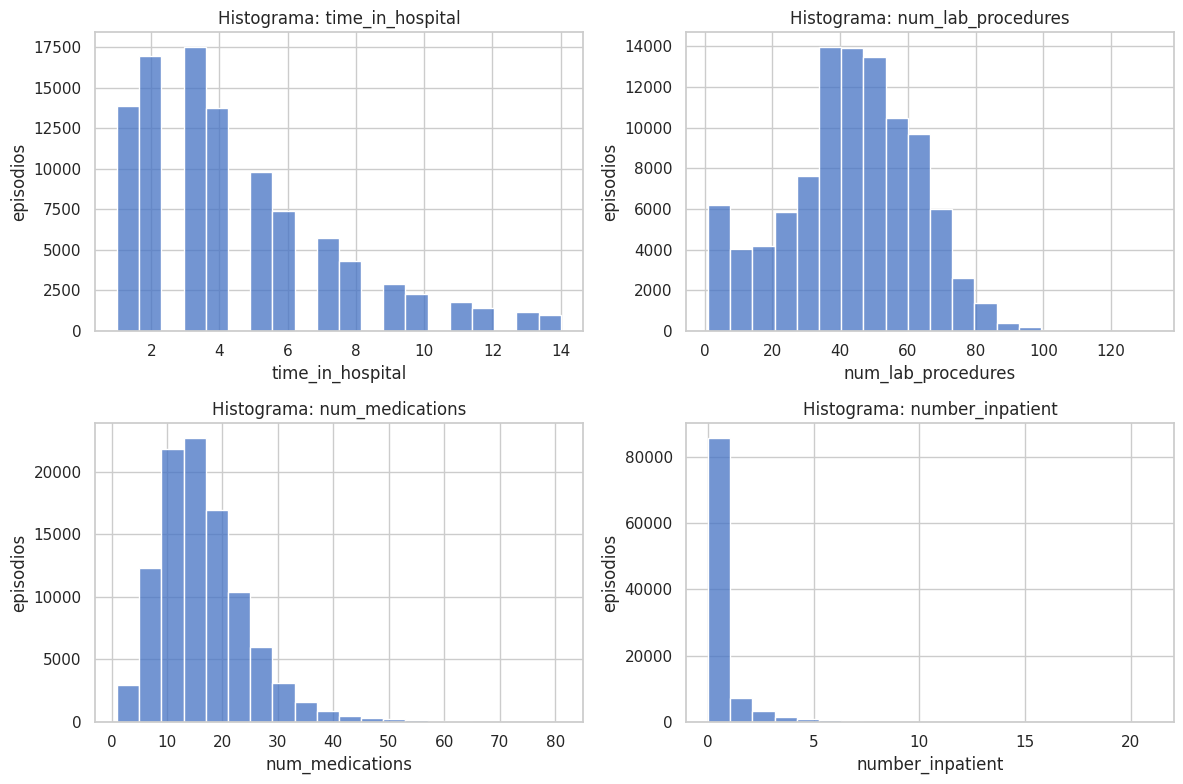

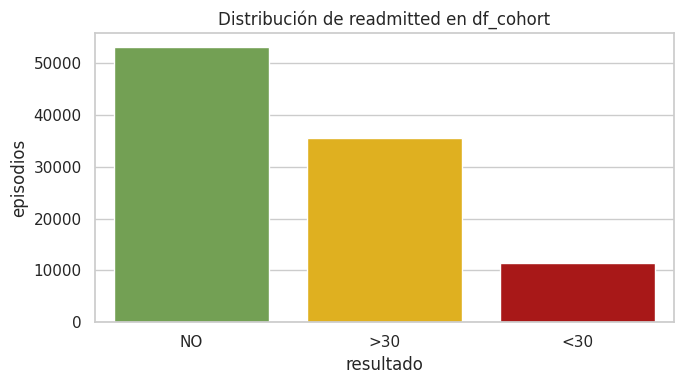

In [7]:
plot_cols = ["time_in_hospital", "num_lab_procedures", "num_medications", "number_inpatient"]

# Histogramas: distribución de cuatro magnitudes.
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, plot_cols):
    sns.histplot(df_cohort[col], bins=20, color="#4472C4", ax=ax)
    ax.set_title(f"Histograma: {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("episodios")
fig.tight_layout()
guardar(fig, "fig01_histogramas_magnitudes")
display(fig)
plt.close(fig)

# Barra de la variable objetivo.
target_order = ["NO", ">30", "<30"]
counts = df_cohort[target_col].value_counts().reindex(target_order, fill_value=0)
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=counts.index, y=counts.values, hue=counts.index, legend=False, palette=["#70AD47", "#FFC000", "#C00000"], ax=ax)
ax.set_title("Distribución de readmitted en df_cohort")
ax.set_xlabel("resultado")
ax.set_ylabel("episodios")
fig.tight_layout()
guardar(fig, "fig02_distribucion_readmitted")
display(fig)
plt.close(fig)

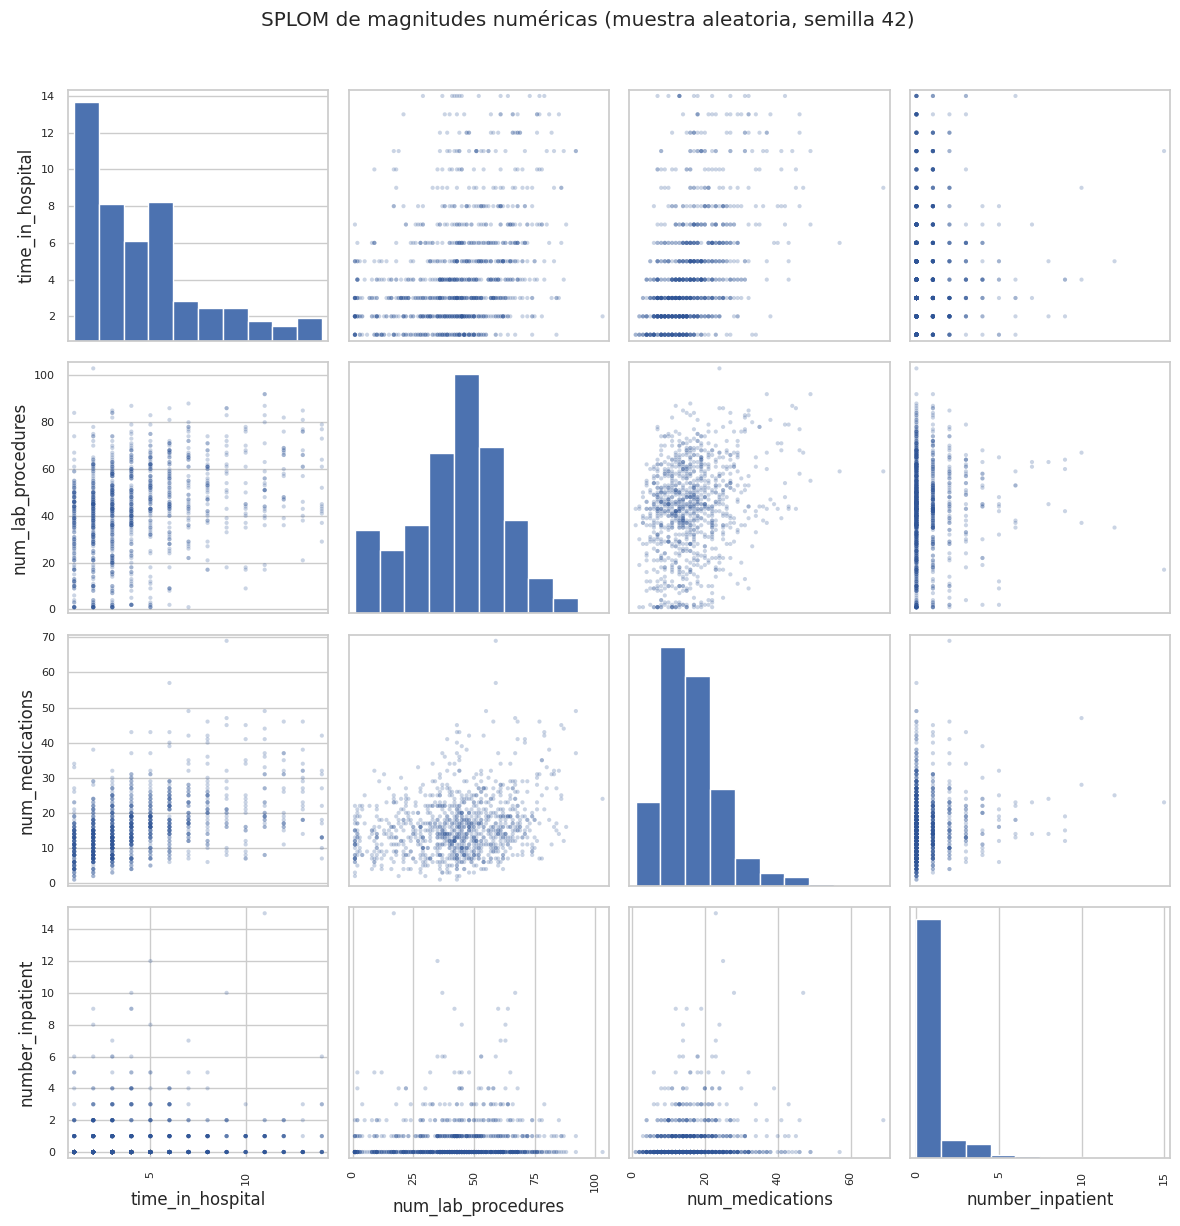

Matriz de covarianza:


,time_in_hospital,num_lab_procedures,num_medications,number_inpatient
time_in_hospital,8.85,18.66,11.17,0.28
num_lab_procedures,18.66,384.98,42.10,0.97
num_medications,11.17,42.10,65.49,0.66
number_inpatient,0.28,0.97,0.66,1.59


Matriz de correlación de Pearson:


,time_in_hospital,num_lab_procedures,num_medications,number_inpatient
time_in_hospital,1.00,0.32,0.46,0.07
num_lab_procedures,0.32,1.00,0.27,0.04
num_medications,0.46,0.27,1.00,0.06
number_inpatient,0.07,0.04,0.06,1.00


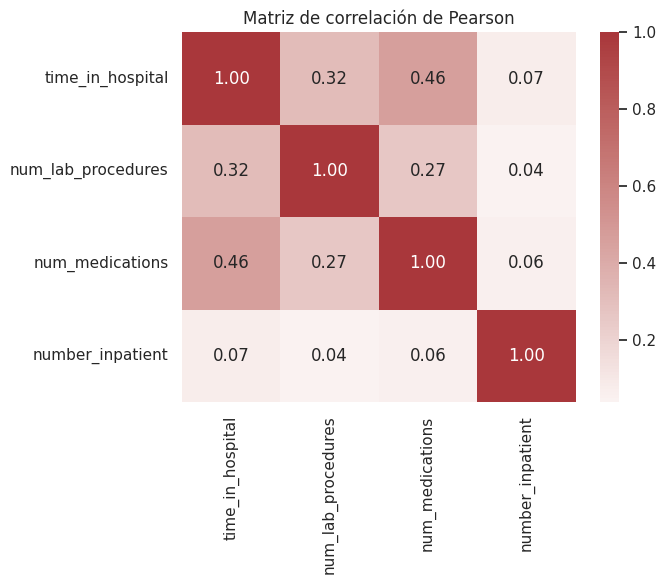

In [8]:
# SPLOM: muestra fija para mantener la figura legible.
splom_data = df_cohort[plot_cols].sample(n=min(1000, len(df_cohort)), random_state=SEED)
axes = pd.plotting.scatter_matrix(splom_data, figsize=(12, 12), diagonal="hist", alpha=0.25, color="#2F5597")
fig = plt.gcf()
fig.suptitle("SPLOM de magnitudes numéricas (muestra aleatoria, semilla 42)", y=1.02)
fig.tight_layout()
guardar(fig, "fig03_splom_magnitudes")
display(fig)
plt.close(fig)

covariance = df_cohort[plot_cols].cov()
correlation = df_cohort[plot_cols].corr()
print("Matriz de covarianza:")
display(covariance.round(2))
print("Matriz de correlación de Pearson:")
display(correlation.round(2))
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax)
ax.set_title("Matriz de correlación de Pearson")
fig.tight_layout()
guardar(fig, "fig04_correlacion_pearson")
display(fig)
plt.close(fig)

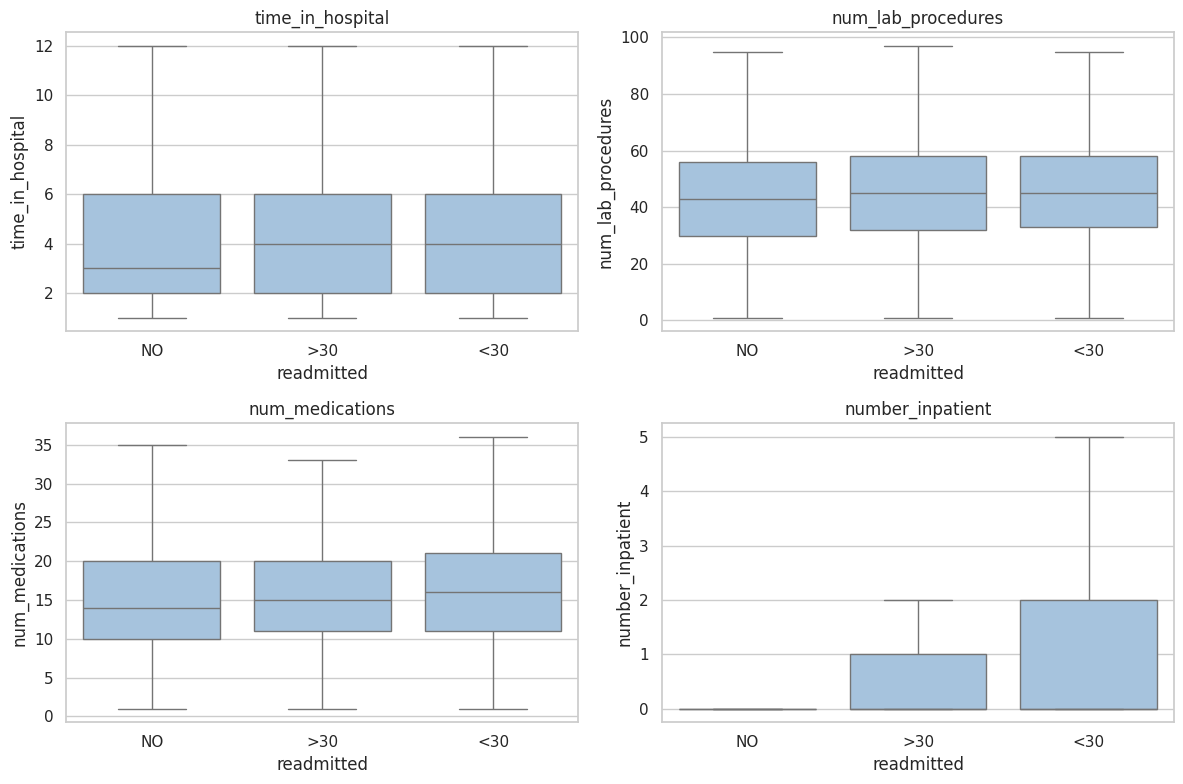

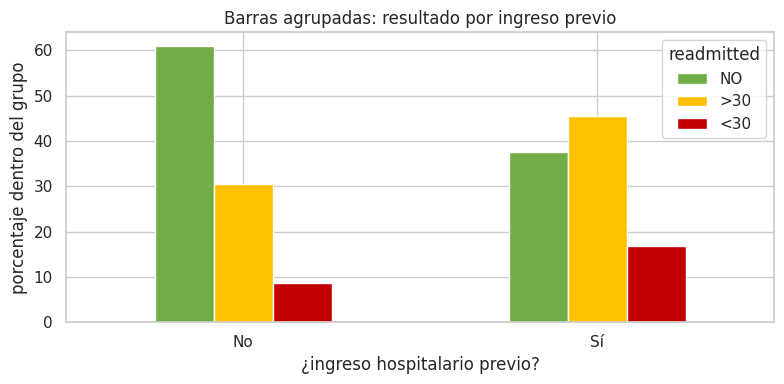

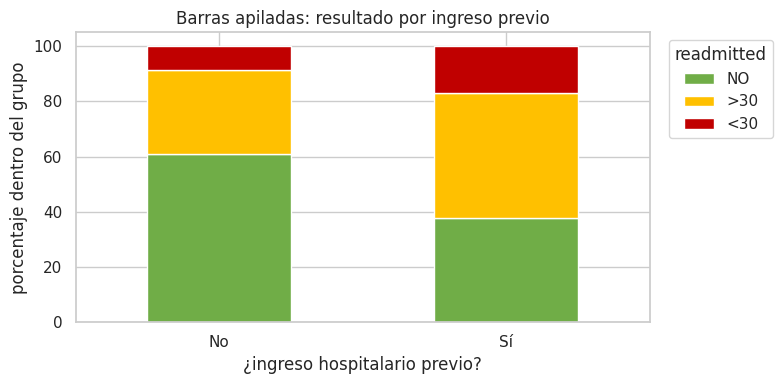

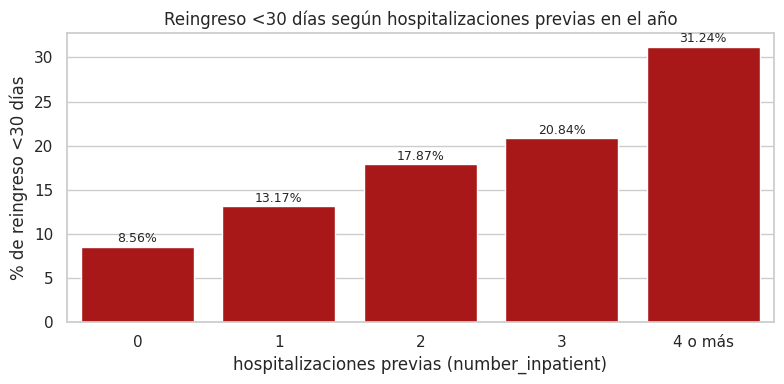

Gradiente de reingreso por hospitalizaciones previas:


,episodios,tasa_menos_30
0,66672,8.56
1,19163,13.17
2,7382,17.87
3,3321,20.84
4 o más,3576,31.24


In [9]:
# Cajas por resultado.
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, plot_cols):
    sns.boxplot(data=df_cohort, x=target_col, y=col, order=target_order, showfliers=False, color="#9DC3E6", ax=ax)
    ax.set_title(col)
    ax.set_xlabel("readmitted")
fig.tight_layout()
guardar(fig, "fig05_cajas_por_resultado")
display(fig)
plt.close(fig)

# Barras agrupadas y apiladas: resultado según existencia de ingreso previo.
with_prior = df_cohort.assign(ingreso_previo=np.where(df_cohort["number_inpatient"] > 0, "Sí", "No"))
resultado_por_prior = pd.crosstab(with_prior["ingreso_previo"], with_prior[target_col], normalize="index").reindex(columns=target_order, fill_value=0)
resultado_por_prior = resultado_por_prior.reindex(["No", "Sí"])

ax = (resultado_por_prior * 100).plot(kind="bar", figsize=(8, 4), color=["#70AD47", "#FFC000", "#C00000"])
ax.set_title("Barras agrupadas: resultado por ingreso previo")
ax.set_xlabel("¿ingreso hospitalario previo?")
ax.set_ylabel("porcentaje dentro del grupo")
ax.legend(title="readmitted")
plt.xticks(rotation=0)
fig = ax.figure
fig.tight_layout()
guardar(fig, "fig06_barras_agrupadas_ingreso_previo")
display(fig)
plt.close(fig)

ax = (resultado_por_prior * 100).plot(kind="bar", stacked=True, figsize=(8, 4), color=["#70AD47", "#FFC000", "#C00000"])
ax.set_title("Barras apiladas: resultado por ingreso previo")
ax.set_xlabel("¿ingreso hospitalario previo?")
ax.set_ylabel("porcentaje dentro del grupo")
ax.legend(title="readmitted", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=0)
fig = ax.figure
fig.tight_layout()
guardar(fig, "fig07_barras_apiladas_ingreso_previo")
display(fig)
plt.close(fig)

# Gradiente completo de hospitalizaciones previas (sostiene el baseline B2 de E1).
grad = (
    df_cohort.assign(previos=df_cohort["number_inpatient"].clip(upper=4))
    .groupby("previos")[target_col]
    .agg(episodios="size", tasa_menos_30=lambda s: s.eq("<30").mean() * 100)
)
grad.index = ["0", "1", "2", "3", "4 o más"]
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=grad.index, y=grad["tasa_menos_30"], color="#C00000", ax=ax)
for i, v in enumerate(grad["tasa_menos_30"]):
    ax.text(i, v + 0.5, f"{v:.2f}%", ha="center", fontsize=9)
ax.set_title("Reingreso <30 días según hospitalizaciones previas en el año")
ax.set_xlabel("hospitalizaciones previas (number_inpatient)")
ax.set_ylabel("% de reingreso <30 días")
fig.tight_layout()
guardar(fig, "fig08_gradiente_ingresos_previos")
display(fig)
plt.close(fig)
print("Gradiente de reingreso por hospitalizaciones previas:")
display(grad.round(2))


### Tres hallazgos cuantificados

Cada hallazgo combina cifra, interpretación, consecuencia y evidencia. Son
asociaciones de esta muestra, no efectos clínicos ni promesas de reducción del
reingreso.

In [10]:
# Cifras de los tres hallazgos, calculadas en vivo sobre df_cohort.
porcentaje_temprano = df_cohort[target_col].eq("<30").mean() * 100

# Hallazgo 2: HbA1c medida frente a no medida.
a1c_medida = df_cohort["A1Cresult"].notna()
tasa_a1c_si = df_cohort.loc[a1c_medida, target_col].eq("<30").mean() * 100
tasa_a1c_no = df_cohort.loc[~a1c_medida, target_col].eq("<30").mean() * 100
falta_a1c = (~a1c_medida).mean() * 100

# Hallazgo 3: gradiente completo de hospitalizaciones previas.
sin_previos = df_cohort.loc[df_cohort["number_inpatient"] == 0, target_col].eq("<30").mean() * 100
cuatro_mas = df_cohort.loc[df_cohort["number_inpatient"] >= 4, target_col].eq("<30").mean() * 100
n_cuatro_mas = int((df_cohort["number_inpatient"] >= 4).sum())

hallazgos_md = f"""
#### Hallazgo 1 — El resultado de interés es minoritario

`<30` representa el **{porcentaje_temprano:.2f} %** de los {len(df_cohort):,} episodios de `df_cohort`.

> **Interpretación:** casi nueve de cada diez episodios no terminan en reingreso temprano.
>
> **Consecuencia:** la exactitud es inservible como métrica — un clasificador que prediga
> «nadie reingresa» acertaría el {100 - porcentaje_temprano:.2f} %. La métrica primaria declarada en E1
> es Recall@K, con K igual a la capacidad de seguimiento del equipo.
>
> **Evidencia:** `reports/figures/fig02_distribucion_readmitted.png` y la tabla de la tarea 2.2.

---

#### Hallazgo 2 — La ausencia de HbA1c no es ruido

La HbA1c falta en el **{falta_a1c:.2f} %** de los episodios. Los que **sí** la tienen registrada
reingresan **{tasa_a1c_si:.2f} %** frente a **{tasa_a1c_no:.2f} %** de los que no — es decir,
medirla se asocia a *menos* reingreso, al revés de lo esperado.

> **Interpretación:** la especialista consultada (entrevista E-01, 4 de septiembre de 2026) lo lee
> como marcador de inicio temprano de insulina: la prueba no protege, identifica a un paciente
> que ya está siendo manejado de forma más activa.
>
> **Consecuencia:** la ausencia se modela como señal mediante un indicador binario y **no se imputa**.
> Imputar un valor plausible borraría justamente la información que distingue a los dos grupos.
>
> **Evidencia:** tabla de faltantes de la tarea 2.4 y celda de cálculo de esta sección.

---

#### Hallazgo 3 — Las hospitalizaciones previas ordenan el riesgo

El reingreso `<30` pasa de **{sin_previos:.2f} %** en episodios sin hospitalizaciones previas en el año
a **{cuatro_mas:.2f} %** en quienes tuvieron cuatro o más ({n_cuatro_mas:,} episodios), con gradiente
monótono entre ambos extremos.

> **Interpretación:** es la señal simple más fuerte encontrada en el conjunto. Es una asociación
> descriptiva de esta muestra, no un efecto causal.
>
> **Consecuencia:** sostiene el baseline **B2** declarado en E1 —priorizar por ingresos previos—
> que el modelo de E4 deberá superar. Y obliga a agrupar por `patient_nbr` al particionar, porque
> la variable se construye sobre el historial del mismo paciente.
>
> **Evidencia:** `reports/figures/fig08_gradiente_ingresos_previos.png` y la tabla del gradiente.
"""

display(Markdown(hallazgos_md))



#### Hallazgo 1 — El resultado de interés es minoritario

`<30` representa el **11.34 %** de los 100,114 episodios de `df_cohort`.

> **Interpretación:** casi nueve de cada diez episodios no terminan en reingreso temprano.
>
> **Consecuencia:** la exactitud es inservible como métrica — un clasificador que prediga
> «nadie reingresa» acertaría el 88.66 %. La métrica primaria declarada en E1
> es Recall@K, con K igual a la capacidad de seguimiento del equipo.
>
> **Evidencia:** `reports/figures/fig02_distribucion_readmitted.png` y la tabla de la tarea 2.2.

---

#### Hallazgo 2 — La ausencia de HbA1c no es ruido

La HbA1c falta en el **83.14 %** de los episodios. Los que **sí** la tienen registrada
reingresan **9.93 %** frente a **11.63 %** de los que no — es decir,
medirla se asocia a *menos* reingreso, al revés de lo esperado.

> **Interpretación:** la especialista consultada (entrevista E-01, 4 de septiembre de 2026) lo lee
> como marcador de inicio temprano de insulina: la prueba no protege, identifica a un paciente
> que ya está siendo manejado de forma más activa.
>
> **Consecuencia:** la ausencia se modela como señal mediante un indicador binario y **no se imputa**.
> Imputar un valor plausible borraría justamente la información que distingue a los dos grupos.
>
> **Evidencia:** tabla de faltantes de la tarea 2.4 y celda de cálculo de esta sección.

---

#### Hallazgo 3 — Las hospitalizaciones previas ordenan el riesgo

El reingreso `<30` pasa de **8.56 %** en episodios sin hospitalizaciones previas en el año
a **31.24 %** en quienes tuvieron cuatro o más (3,576 episodios), con gradiente
monótono entre ambos extremos.

> **Interpretación:** es la señal simple más fuerte encontrada en el conjunto. Es una asociación
> descriptiva de esta muestra, no un efecto causal.
>
> **Consecuencia:** sostiene el baseline **B2** declarado en E1 —priorizar por ingresos previos—
> que el modelo de E4 deberá superar. Y obliga a agrupar por `patient_nbr` al particionar, porque
> la variable se construye sobre el historial del mismo paciente.
>
> **Evidencia:** `reports/figures/fig08_gradiente_ingresos_previos.png` y la tabla del gradiente.


# 2.4 · Verificar la calidad de los datos

Las tasas de calidad de esta sección se calculan sobre `df_parquet`, es decir,
sobre las **50 columnas y todos los episodios originales**. `df_cohort` se usa
solo para explorar. No se imputan valores, no se recortan atípicos y no se
borran filas en E2.

In [11]:
# Faltantes y texto literal "None" en las 50 columnas originales.
missing_table = pd.DataFrame({
    "n faltantes": df_parquet.isna().sum(),
    "% faltantes": df_parquet.isna().mean() * 100,
    "cardinalidad no nula": df_parquet.nunique(dropna=True),
}).sort_values("% faltantes", ascending=False)
print(f"Celdas faltantes en las 50 columnas originales: {int(df_parquet.isna().sum().sum()):,} ({df_parquet.isna().mean().mean() * 100:.2f}% del total)")
print("La siguiente tabla y sus porcentajes usan siempre df_parquet (raw completo):")
display(missing_table.round(2))

literal_none = sum((df_parquet[c].astype("string") == "None").sum() for c in df_parquet.columns)
unknown_gender = int((df_parquet["gender"] == "Unknown/Invalid").sum())
print(f"Cadenas literales 'None': {literal_none}; gender='Unknown/Invalid': {unknown_gender} filas. Se documentan, no se convierten silenciosamente.")

Celdas faltantes en las 50 columnas originales: 374,017 (7.35% del total)
La siguiente tabla y sus porcentajes usan siempre df_parquet (raw completo):


,n faltantes,% faltantes,cardinalidad no nula
weight,98569,96.86,9
max_glu_serum,96420,94.75,3
A1Cresult,84748,83.28,3
medical_specialty,49949,49.08,72
payer_code,40256,39.56,17
race,2273,2.23,5
diag_3,1423,1.40,789
diag_2,358,0.35,748
diag_1,21,0.02,716
patient_nbr,0,0.00,71518


Cadenas literales 'None': 0; gender='Unknown/Invalid': 3 filas. Se documentan, no se convierten silenciosamente.


In [12]:
# Códigos administrativos relevantes según el diccionario concatenado.
quality_codes = []
for variable, grupo in mapping_table.groupby("variable"):
    observed = df_parquet[variable].value_counts(dropna=False)
    for _, row in grupo.iterrows():
        description = row["description"]
        lower = description.lower()
        code = row["codigo"]
        is_death = variable == "discharge_disposition_id" and code in death_codes
        is_special = is_death or any(word in lower for word in ["null", "not mapped", "not available", "unknown", "invalid"])
        if is_special:
            n = int(observed.get(code, 0))
            quality_codes.append({
                "variable": variable,
                "codigo": code,
                "description": description,
                "n en raw": n,
                "% en raw": n / len(df_parquet) * 100,
                "tratamiento": "separar fallecimientos para la vista; conservar raw" if is_death else "conservar y revisar",
            })
display(pd.DataFrame(quality_codes).round(2))

controls = pd.DataFrame([
    {"control": "filas exactas duplicadas", "n": int(df_parquet.duplicated().sum())},
    {"control": "encounter_id repetido", "n": int(df_parquet["encounter_id"].duplicated().sum())},
    {"control": "pacientes con más de un episodio", "n": int(df_parquet.loc[df_parquet["patient_nbr"].duplicated(keep=False), "patient_nbr"].nunique())},
    {"control": "filas de pacientes repetidos", "n": int(df_parquet["patient_nbr"].duplicated(keep=False).sum())},
])
print("Duplicados y repetición de identificadores en el raw:")
display(controls)

,variable,codigo,description,n en raw,% en raw,tratamiento
0,admission_source_id,9,Not Available,125,0.12,conservar y revisar
1,admission_source_id,15,Not Available,0,0.00,conservar y revisar
2,admission_source_id,17,NULL,6781,6.66,conservar y revisar
3,admission_source_id,20,Not Mapped,161,0.16,conservar y revisar
4,admission_source_id,21,Unknown/Invalid,0,0.00,conservar y revisar
5,admission_type_id,5,Not Available,4785,4.70,conservar y revisar
6,admission_type_id,6,NULL,5291,5.20,conservar y revisar
7,admission_type_id,8,Not Mapped,320,0.31,conservar y revisar
8,discharge_disposition_id,11,Expired,1642,1.61,separar fallecimientos para la vista; conserva...
9,discharge_disposition_id,18,NULL,3691,3.63,conservar y revisar


Duplicados y repetición de identificadores en el raw:


,control,n
0,filas exactas duplicadas,0
1,encounter_id repetido,0
2,pacientes con más de un episodio,16773
3,filas de pacientes repetidos,47021


In [13]:
# Atípicos descriptivos con la regla IQR; no se eliminan.
outlier_rows = []
for col in numericas_cols:
    serie = df_parquet[col]
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    fuera = (serie < q1 - 1.5 * iqr) | (serie > q3 + 1.5 * iqr)
    outlier_rows.append({
        "variable": col,
        "q1": q1,
        "q3": q3,
        "n fuera de IQR": int(fuera.sum()),
        "% fuera de IQR": fuera.mean() * 100,
        "decisión": "bandera descriptiva; no borrar ni recortar",
    })
display(pd.DataFrame(outlier_rows).set_index("variable").round(2))

# Representatividad básica de la cohorte exploratoria.
representacion = []
for col in ["age", "gender", "race"]:
    tabla = df_cohort.groupby(col, dropna=False)[target_col].agg(
        n="size", porcentaje_muestra=lambda s: s.size / len(df_cohort) * 100,
        porcentaje_menos_30=lambda s: s.eq("<30").mean() * 100,
    ).reset_index()
    # Nombre común para la columna de categoría: evita columnas sueltas al concatenar.
    tabla = tabla.rename(columns={col: "categoria"})
    tabla["categoria"] = tabla["categoria"].astype("object").fillna("(sin dato)")
    tabla.insert(0, "variable", col)
    representacion.append(tabla)
print("Distribución descriptiva por edad, sexo y raza (df_cohort):")
display(pd.concat(representacion, ignore_index=True).round(2))

,q1,q3,n fuera de IQR,% fuera de IQR,decisión
variable,,,,,
time_in_hospital,2.0,6.0,2252,2.21,bandera descriptiva; no borrar ni recortar
num_lab_procedures,31.0,57.0,143,0.14,bandera descriptiva; no borrar ni recortar
num_procedures,0.0,2.0,4954,4.87,bandera descriptiva; no borrar ni recortar
num_medications,10.0,20.0,2557,2.51,bandera descriptiva; no borrar ni recortar
number_outpatient,0.0,0.0,16739,16.45,bandera descriptiva; no borrar ni recortar
number_emergency,0.0,0.0,11383,11.19,bandera descriptiva; no borrar ni recortar
number_inpatient,0.0,1.0,7049,6.93,bandera descriptiva; no borrar ni recortar
number_diagnoses,6.0,9.0,281,0.28,bandera descriptiva; no borrar ni recortar


Distribución descriptiva por edad, sexo y raza (df_cohort):


,variable,categoria,n,porcentaje_muestra,porcentaje_menos_30
0,age,[0-10),160,0.16,1.88
1,age,[10-20),690,0.69,5.80
2,age,[20-30),1650,1.65,14.30
3,age,[30-40),3765,3.76,11.26
4,age,[40-50),9626,9.62,10.67
5,age,[50-60),17102,17.08,9.75
6,age,[60-70),22185,22.16,11.28
7,age,[70-80),25562,25.53,12.01
8,age,[80-90),16706,16.69,12.44
9,age,[90-100),2668,2.66,11.62


### Plan de calidad, limitaciones y cierre

- `weight`, `max_glu_serum`, `A1Cresult`, `medical_specialty`, `payer_code` y
`race` tienen ausencia importante. Se propone conservar indicadores de
ausencia y revisar utilidad con un experto; no imputar automáticamente en E2.
- Los valores fuera de IQR pueden ser válidos. Se mantienen y se revisarán en
E3; los códigos `Unknown/Invalid` se reportan sin eliminar episodios.
- `patient_nbr` se repite. Toda partición o evaluación posterior debe agrupar
por paciente para evitar fuga entre episodios.
- La muestra es histórica y proviene de hospitales de Estados Unidos, pero no
contiene el hospital. No se puede asegurar representatividad de otros centros,
países o periodos; tampoco se puede medir una tasa diaria porque no hay fechas.
- `<30` es un resultado observado, no una prueba de que el reingreso sea
prevenible. Faltan capacidad real de seguimiento, variables temporales,
validación clínica y criterios éticos para una intervención.

**Cierre:** los datos permiten continuar **con mitigaciones**: conservar el raw,
separar fallecimientos, documentar faltantes y códigos, agrupar por paciente y
revisar representatividad. Este notebook no entrena ni evalúa ningún modelo.

In [14]:
quality_plan = pd.DataFrame([
    {"variable": "weight / resultados de laboratorio", "problema": "ausencia alta y categorías agrupadas", "siguiente paso": "indicador de ausencia y revisión clínica; no imputar automáticamente"},
    {"variable": "medical_specialty / payer_code / race", "problema": "cobertura diferencial", "siguiente paso": "auditar representación y uso ético"},
    {"variable": "diag_1, diag_2, diag_3", "problema": "faltantes y alta cardinalidad", "siguiente paso": "agrupar solo con aprobación clínica"},
    {"variable": "patient_nbr", "problema": "episodios repetidos por paciente", "siguiente paso": "particiones agrupadas; no deduplicar raw"},
    {"variable": "magnitudes numéricas", "problema": "ceros y valores fuera de IQR", "siguiente paso": "conservar y revisar antes de transformar"},
])
display(quality_plan)
print()
print("Respuesta a la pregunta que cierra la etapa 2:")
print("¿Los datos alcanzan para el objetivo de minería de la tarea 1.3?")
print("  -> Sí, con las mitigaciones anotadas.")
print("     Mitigaciones: separar fallecimientos, indicador de ausencia en lugar de imputación,")
print("     particiones agrupadas por patient_nbr, y declaración de no transportabilidad.")


,variable,problema,siguiente paso
0,weight / resultados de laboratorio,ausencia alta y categorías agrupadas,indicador de ausencia y revisión clínica; no i...
1,medical_specialty / payer_code / race,cobertura diferencial,auditar representación y uso ético
2,"diag_1, diag_2, diag_3",faltantes y alta cardinalidad,agrupar solo con aprobación clínica
3,patient_nbr,episodios repetidos por paciente,particiones agrupadas; no deduplicar raw
4,magnitudes numéricas,ceros y valores fuera de IQR,conservar y revisar antes de transformar



Respuesta a la pregunta que cierra la etapa 2:
¿Los datos alcanzan para el objetivo de minería de la tarea 1.3?
  -> Sí, con las mitigaciones anotadas.
     Mitigaciones: separar fallecimientos, indicador de ausencia en lugar de imputación,
     particiones agrupadas por patient_nbr, y declaración de no transportabilidad.
